In [305]:
#Load Dataset

import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
file_path = '/kaggle/input/datasets/organizations/uciml/iris/Iris.csv'
df = pd.read_csv(file_path)

X = df.drop(columns=['Id', 'Species'])
y = df['Species']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (120, 4)
Testing data shape: (30, 4)


In [306]:
#Shuffle Dataset

from sklearn.utils import shuffle

X_train, y_train = shuffle(X_train, y_train, random_state=42)

# Definition of Classes

1. Layer_Dense Class
2. Activaiton Functions
3. Loss Function Class (MSE)

In [307]:
import numpy as np

# Dense layer class
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = np.random.randn(n_inputs, n_neurons) * np.sqrt(2.0 / n_inputs) #Kaiming Initialization
        self.biases = np.zeros((1, n_neurons))

    def forward(self, inputs):
        self.output = np.dot(inputs, self.weights) + self.biases

    def gradient(self, inputs, output_gradients):
        self.weights_gradient = np.dot(inputs.T, output_gradients)
        self.biases_gradient = np.sum(output_gradients, axis=0, keepdims=True)
        self.input_gradients = np.dot(output_gradients, self.weights.T)

class Activation_ReLU:
    def forward(self, inputs):
        self.output = np.maximum(0, inputs)

    def gradient(self, output_gradients):
        self.input_gradients = output_gradients.copy() 
        self.input_gradients[self.output <= 0] = 0 

class Activation_Softmax:
    def forward(self, inputs):
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        self.output = exp_values / np.sum(exp_values, axis=1, keepdims=True)

    def gradient(self, output_gradients):
        
        self.input_gradients = np.empty_like(output_gradients)
        for index, (single_output, single_gradient) in enumerate(zip(self.output, output_gradients)):
            # Flatten the output array
            single_output = single_output.reshape(-1, 1)
            
            # Calculate the Jacobian matrix of the softmax function
            jacobian_matrix = np.diagflat(single_output) - np.dot(single_output, single_output.T)
            
            # Multiply the Jacobian matrix by the incoming loss gradient
            self.input_gradients[index] = np.dot(jacobian_matrix, single_gradient)

class Loss_CategoricalCrossEntropy:

    def __init__(self):
        self.dinputs = None

    def forward(self, y_pred, y_true):
        # Clip values to prevent log(0) errors
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
        
        # Calculate loss (dot product of true and log of pred)
        sample_losses = -np.sum(y_true * np.log(y_pred_clipped), axis=1)
        return np.mean(sample_losses)

    def backward(self, y_pred, y_true):
        # Number of samples
        samples = len(y_pred)
        self.dinputs = -1 * y_true / y_pred
        self.dinputs = self.dinputs / samples

epoch 0: loss 1.2189806101386904
epoch 10: loss 0.8155005568705189
epoch 20: loss 0.5870217440681547
epoch 30: loss 0.4767301083998481
epoch 40: loss 0.4022227272152226
epoch 50: loss 0.3459588260451677
epoch 60: loss 0.30328625388183506
epoch 70: loss 0.27104659598697994
epoch 80: loss 0.2461139601158644
epoch 90: loss 0.2265811103024108
epoch 100: loss 0.211095314287603
epoch 110: loss 0.19841055270439617
epoch 120: loss 0.18794632101616976
epoch 130: loss 0.17912009013653313
epoch 140: loss 0.17164269200189652
epoch 150: loss 0.16521397739659105
epoch 160: loss 0.1596544303683633
epoch 170: loss 0.15481334139683495
epoch 180: loss 0.150565877749757
epoch 190: loss 0.14682489234049


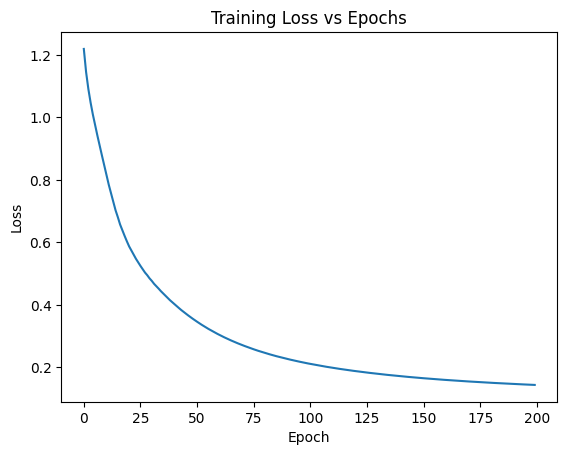

In [308]:
hl1 = Layer_Dense(4, 10)
activation1 = Activation_ReLU()

hl2 = Layer_Dense(10, 3)
activation2 = Activation_Softmax()

cce_loss = Loss_CategoricalCrossEntropy()

alpha = 0.01
epochs = 200
batch_size = 8

import matplotlib.pyplot as plt

# Prepare target and a list to keep track of loss
y_train_encoded = pd.get_dummies(y_train).to_numpy()
loss_history = []

for epoch in range(epochs):
    for i in range(0, len(X_train), batch_size):
        # Slice the batch
        batch_x = X_train.iloc[i:i+batch_size].to_numpy()
        batch_y = y_train_encoded[i:i+batch_size]
        
        # 2. Forward pass (stays the same)
        hl1.forward(batch_x)
        activation1.forward(hl1.output)
        hl2.forward(activation1.output)
        activation2.forward(hl2.output)

        # 3. Calculate Loss using CCE
        current_loss = cce_loss.forward(activation2.output, batch_y)

        # 4. Backward Pass
        # Use the new cce_loss object here
        cce_loss.backward(activation2.output, batch_y)
        
        activation2.gradient(cce_loss.dinputs)
        hl2.gradient(activation1.output, activation2.input_gradients)
        
        activation1.gradient(hl2.input_gradients)
        hl1.gradient(batch_x, activation1.input_gradients)
        
        # Update weights
        hl1.weights += -alpha * hl1.weights_gradient
        hl1.biases += -alpha * hl1.biases_gradient
        
        hl2.weights += -alpha * hl2.weights_gradient
        hl2.biases += -alpha * hl2.biases_gradient
        
    loss_history.append(current_loss)
    if(epoch%10==0):
        print(f"epoch {epoch}: loss {current_loss}")

# Plot the results
plt.plot(loss_history)
plt.title('Training Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


Test Set Accuracy: 93.33%


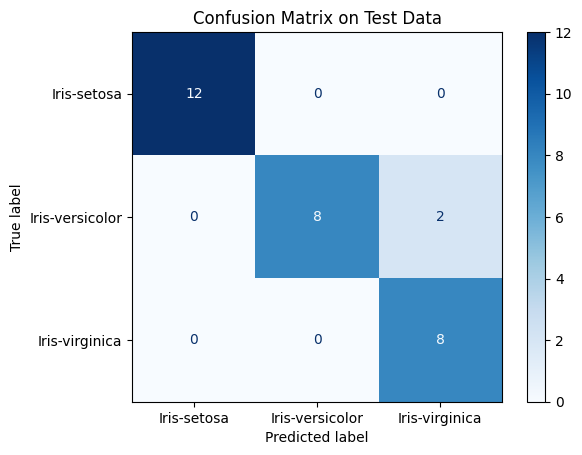

In [309]:
# Accuracy and Confusion Matrix

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Run forward pass on test data
hl1.forward(X_test.to_numpy())
activation1.forward(hl1.output)

hl2.forward(activation1.output)
activation2.forward(hl2.output)

# 2. Get predictions by finding the index of the highest probability
predictions = np.argmax(activation2.output, axis=1)

# 3. Convert true labels to numeric indices to match predictions
# We use the unique classes found in training to create the mapping
unique_classes = sorted(y_train.unique())
y_test_numeric = y_test.map({label: i for i, label in enumerate(unique_classes)})

# 4. Display Accuracy
acc = accuracy_score(y_test_numeric, predictions)
print(f"Test Set Accuracy: {acc * 100:.2f}%")

# 5. Display Confusion Matrix
cm = confusion_matrix(y_test_numeric, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_classes)

disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix on Test Data')
plt.show()

In [310]:
# Predictions

predicted_labels = [unique_classes[i] for i in predictions]

results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predicted_labels
})

results_df['Correct'] = results_df['Actual'] == results_df['Predicted']
print(results_df)

             Actual        Predicted  Correct
0    Iris-virginica   Iris-virginica     True
1       Iris-setosa      Iris-setosa     True
2    Iris-virginica   Iris-virginica     True
3       Iris-setosa      Iris-setosa     True
4    Iris-virginica   Iris-virginica     True
5    Iris-virginica   Iris-virginica     True
6   Iris-versicolor  Iris-versicolor     True
7   Iris-versicolor  Iris-versicolor     True
8       Iris-setosa      Iris-setosa     True
9   Iris-versicolor  Iris-versicolor     True
10  Iris-versicolor   Iris-virginica    False
11      Iris-setosa      Iris-setosa     True
12      Iris-setosa      Iris-setosa     True
13  Iris-versicolor  Iris-versicolor     True
14      Iris-setosa      Iris-setosa     True
15  Iris-versicolor   Iris-virginica    False
16      Iris-setosa      Iris-setosa     True
17  Iris-versicolor  Iris-versicolor     True
18  Iris-versicolor  Iris-versicolor     True
19  Iris-versicolor  Iris-versicolor     True
20   Iris-virginica   Iris-virgini

In [311]:
# False Predictions

import numpy as np

true_vals = np.array(y_test_numeric)
wrong_idx = np.where(predictions != true_vals)[0]

if len(wrong_idx) == 0:
    print("100% accuracy! No wrong predictions to analyze.")
else:
    print(f"Found {len(wrong_idx)} mistake(s). Let's look at the confidence:\n")
    
    for i in wrong_idx:
        t_idx = true_vals[i]
        p_idx = predictions[i]
        
        t_name = unique_classes[t_idx]
        p_name = unique_classes[p_idx]
        
        # get the 3 softmax probabilities for this specific test item
        probs = activation2.output[i]
        
        p_conf = probs[p_idx] * 100
        t_conf = probs[t_idx] * 100
        
        print(f"Test Row {i}:")
        print(f" Actual:    {t_name} (Model gave it {t_conf:.2f}%)")
        print(f" Predicted: {p_name} (Model gave it {p_conf:.2f}%)")
        
        # optional: show the raw array just to see all 3 values
        rounded_probs = [round(p, 4) for p in probs]
        print(f" All probs: {rounded_probs}")
        print("-" * 40)

Found 2 mistake(s). Let's look at the confidence:

Test Row 10:
 Actual:    Iris-versicolor (Model gave it 27.67%)
 Predicted: Iris-virginica (Model gave it 72.30%)
 All probs: [np.float64(0.0003), np.float64(0.2767), np.float64(0.723)]
----------------------------------------
Test Row 15:
 Actual:    Iris-versicolor (Model gave it 19.97%)
 Predicted: Iris-virginica (Model gave it 80.02%)
 All probs: [np.float64(0.0001), np.float64(0.1997), np.float64(0.8002)]
----------------------------------------
